In [2]:
import matplotlib.pyplot as plt 
from parallel_RLNN import *

In [3]:
S0 = 50  # Initial price
sigma = 0.2  # Volatility
K = 50 * 1.2  # Strike price
r = 0.06  # Risk-free rate
T = 1.  # Maturity
M = 4  # Number of monitoring dates
N = 20000  # Number of sample paths
nodes = 16 # Number of hidden units
style = 'put'  # Payoff type
price, weights, errors = RLNN_Algo(S0, K, r, sigma, N, M, T, style, nodes, 0.001)
print("Bermudan Price", price)
print(errors)

188/188 ━━━━━━━━━━━━━━━━━━━━ 0s 206us/step
Epoch 689: early stopping
Restoring model weights from the end of the best epoch: 669.
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 175us/step
Epoch 162: early stopping
Restoring model weights from the end of the best epoch: 142.
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 175us/step
Epoch 209: early stopping
Restoring model weights from the end of the best epoch: 189.
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 171us/step
Bermudan Price 9.478094831010033
[2.813479001996824e-06, 0.0011545929269552687, 0.0018630233738016692, 0.0012131935330593326]


In [5]:
S0 = 50  # Initial price
sigma = 0.2  # Volatility
K = 50  # Strike price
r = 0.06  # Risk-free rate
T = 1.  # Maturity
M = 4  # Number of monitoring dates
N = 20000  # Number of sample paths
nodes = 16 # Number of hidden units
style = 'put'  # Payoff type
price3, weights3, errors3 = RLNN_Algo(S0, K, r, sigma, N, M, T, style, nodes, 0.001)
print("Bermudan Price", price3)
print(errors3)

188/188 ━━━━━━━━━━━━━━━━━━━━ 0s 215us/step
Epoch 554: early stopping
Restoring model weights from the end of the best epoch: 534.
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 174us/step
Epoch 208: early stopping
Restoring model weights from the end of the best epoch: 188.
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 178us/step
Epoch 182: early stopping
Restoring model weights from the end of the best epoch: 162.
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 180us/step
Bermudan Price 2.732795807747167
[1.2598961904502332e-11, 0.000580823722572489, 0.0010642632757601924, 0.0013450341389697382]


In [6]:
S0 = 50  # Initial price
sigma = 0.2  # Volatility
K = 0.8 * 50  # Strike price
r = 0.06  # Risk-free rate
T = 1.  # Maturity
M = 4  # Number of monitoring dates
N = 20000  # Number of sample paths
nodes = 16 # Number of hidden units
style = 'put'  # Payoff type
price2, weights2, errors2 = RLNN_Algo(S0, K, r, sigma, N, M, T, style, nodes, 0.001)
print("Bermudan Price", price2)
print(errors2)

188/188 ━━━━━━━━━━━━━━━━━━━━ 0s 215us/step
Epoch 285: early stopping
Restoring model weights from the end of the best epoch: 265.
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 176us/step
Epoch 242: early stopping
Restoring model weights from the end of the best epoch: 222.
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 178us/step
Epoch 81: early stopping
Restoring model weights from the end of the best epoch: 61.
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 178us/step
Bermudan Price 0.303186359248195
[1.0191439584438475e-10, 0.0002296849469514078, 0.00017316596926861245, 0.00015416298972858178]


In [7]:
def portfolio_value(weights, stock_price, r, sigma, dt, S0):
    
    weights_layer1 = weights[0].flatten()
    weights_layer2 = weights[2].flatten()
    bias_layer1 = weights[1]
    bias_layer2 = weights[3][0]
    St = stock_price/S0
    
    cost = bias_layer2
    for i in range(len(weights_layer1)):
        wi, bi = weights_layer1[i], bias_layer1[i]
        
        if wi >= 0 and bi >= 0:
            # Forward Price
            temp_cost = wi * St * np.exp(r * dt) + bi
        elif wi > 0 and bi < 0:
            # European Call Option
            strike = -bi / wi
            temp_cost = wi * black_scholes(St, strike, r, sigma, dt, option_type='call')
        elif wi < 0 and bi > 0:
            # European Put Option
            strike = -bi / wi
            temp_cost = -wi * black_scholes(St, strike, r, sigma, dt, option_type='put')
        else:
            # Expected value is 0
            temp_cost = 0.0
            
        cost += temp_cost * weights_layer2[i]
    
    return cost * np.exp(-r * dt)

In [8]:
def check_payoffs(stock_price, weights, S0):
    """
    Given a single stock_price, compute the total 
    payoff implied by the 2-layer NN with piecewise logic.
    
    :param stock_price:  current price of the underlying (float)
    :param weights:      a tuple/list containing 
                         [weights_layer1, bias_layer1, weights_layer2, bias_layer2]
    :param S0:           normalizing constant (e.g. initial stock price)
    :return:             total payoff (float)
    """
    payoffs = 0.0
    dt = T/M
    
    # Extract layers
    weights_layer1 = weights[0].flatten()  # array of w1_i
    bias_layer1    = weights[1]  # array of b1_i
    weights_layer2 = weights[2].flatten()  # array of w2_i
    bias_layer2    = weights[3][0]  # float or array of length 1

    # Normalize
    normalized_stock = stock_price / S0
    
    # Start from second-layer bias
    # (if bias_layer2 is an array, do bias_layer2[0])
    payoffs = bias_layer2

    # Loop over all first-layer neurons
    for i in range(len(weights_layer1)):
        w1i = weights_layer1[i]
        b1i = bias_layer1[i]
        w2i = weights_layer2[i]

        # Case 1: w1 >= 0, b1 >= 0 => Forward contract
        if w1i >= 0 and b1i >= 0:
            payoffs += w2i * (w1i * normalized_stock + b1i)

        # Case 2: w1 > 0, b1 < 0 => call-like payoff
        elif w1i > 0 and b1i < 0:
            strike_call = -b1i / w1i
            call_payoff = max(normalized_stock - strike_call, 0)
            payoffs += w2i * w1i * call_payoff

        # Case 3: w1 < 0, b1 > 0 => put-like payoff
        elif w1i < 0 and b1i > 0:
            strike_put = -b1i / w1i
            put_payoff = max(strike_put - normalized_stock, 0)
            payoffs -= w2i * w1i * put_payoff

        else:
            # The "else" might be w1 <= 0, b1 <= 0 => payoff is effectively 0
            0.0

    return payoffs


In [9]:
def cal_continuation_value2(weights, no_hidden_units, stock_prices, r, sigma, dt, normalizer):
    """ Calculate the continuation value of the Bermudan option

    Args:
        w1 (array): Weights of the first layer
        b1 (array): Biases of the first layer
        w2 (array): Weights of the second layer
        b2 (float): Biases of the second layer
        no_hidden_units (int): Number of hidden units
        stock_prices (float): Stock prices at time
        r (float): Risk free rate
        sigma (float): volatility
        dt (_type_): time step
        M (_type_): number of simulations(samples)
        normalizer (_type_): normalizer for the stock prices

    Returns:
        _type_: _description_
    """
     ## Get the weights of the model
    w1 = weights[0].reshape(-1)
    b1 = weights[1].reshape(-1)
    w2 = weights[2].reshape(-1)
    b2 = weights[3].reshape(-1)
    normalized_stock_values = stock_prices/normalizer
    continuation_value = 0
    for i in range(no_hidden_units):
        continuation_value += expected_value(w1[i], b1[i], normalized_stock_values, r, sigma, dt) * w2[i]
        #print(continuation_value)
    continuation_value += b2
    
    return continuation_value * np.exp(-r*dt)

In [10]:
def hedging_simulation_proper_pnl(stock_paths, weights, r, sigma, T, M, S0, K, price, hidden_nodes):
    N = len(stock_paths)
    dt = T / M
    hedging_errors = np.zeros(N, dtype=float)

    for i in range(N):
        cash_account = price
        weights_now = weights[-1]
        
        # Initial portfolio setup
        cash_account -= portfolio_value(weights_now, stock_paths[i][0], r, sigma, dt, S0)
        
        #print("cash account at the start", cash_account)
        
        for j in range(1, M):
            cash_account *= np.exp(r * dt)
            
            Exercise_value = payoff_fun(stock_paths[i][j], K, "put")
            weights_next = weights[-(j+1)]
            cont_value = cal_continuation_value2(weights_next, hidden_nodes, stock_paths[i][j], r, sigma, dt, S0)
            
            if Exercise_value > cont_value:
                # At exercise: get payoff from current portfolio and exercise
                portfolio_t = check_payoffs(stock_paths[i][j], weights_now, S0)
                cash_account += portfolio_t
                hedging_errors[i] = cash_account - Exercise_value
                break
            
            # Rebalancing: get payoff from old portfolio, pay for new one
            portfolio_t = check_payoffs(stock_paths[i][j], weights_now, S0)
            cash_account += portfolio_t
            
            weights_now = weights[-(j+1)]
            cash_account -= portfolio_value(weights_now, stock_paths[i][j], r, sigma, dt, S0)
        else:
            cash_account *= np.exp(r * dt)
            portfolio_t = check_payoffs(stock_paths[i][M], weights_now, S0)
            cash_account += portfolio_t
            payoff_T = payoff_fun(stock_paths[i][M], K, "put")
            hedging_errors[i] = cash_account - payoff_T
            
    return hedging_errors

In [11]:
stock_prices = stock_price_simulator(S0, r, sigma, T, M, 10000)
hedge_error1 = hedging_simulation_proper_pnl(stock_prices, weights3, r, sigma, T, M, S0, 50, price3, nodes)

In [12]:
stock_prices = stock_price_simulator(S0, r, sigma, T, M, 10000)
hedge_error08 = hedging_simulation_proper_pnl(stock_prices, weights2, r, sigma, T, M, S0, 50 * 0.8, price2, nodes)

In [13]:
stock_prices = stock_price_simulator(S0, r, sigma, T, M, 10000)
hedge_error12 = hedging_simulation_proper_pnl(stock_prices, weights, r, sigma, T, M, S0, 50 * 1.2, price, nodes)

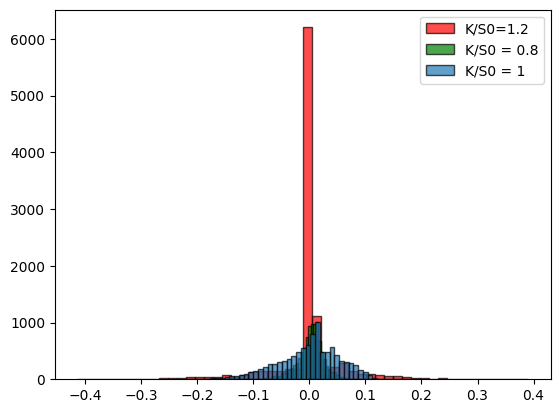

In [14]:
plt.hist(hedge_error12,bins=50, edgecolor='black',color='r', alpha=0.7, label='K/S0=1.2')
plt.hist(hedge_error08, bins=50, edgecolor='k',color='g',  alpha=0.7, label='K/S0 = 0.8')
plt.hist(hedge_error1, bins=50, edgecolor='k', alpha=0.7, label='K/S0 = 1')
plt.legend()
plt.show()
